Ideas:
1. Simulated Anealing Approach?

In [4]:
!pip install shapely
!pip install matplotlib
!pip install numpy
!pip install pandas

In [5]:
import shapely
print(f'Using shapely {shapely.__version__}')

Using shapely 2.1.2


In [6]:
import math
import os
import random
from decimal import Decimal, getcontext

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from matplotlib.patches import Rectangle
from shapely import affinity, touches
from shapely.geometry import Polygon
from shapely.ops import unary_union
from shapely.strtree import STRtree

pd.set_option('display.float_format', '{:.12f}'.format)

# Set precision for Decimal
getcontext().prec = 25
scale_factor = Decimal('1e15')

In [7]:
# Build the index of the submission, in the format:
#  <trees_in_problem>_<tree_index>

index = [f'{n:03d}_{t}' for n in range(1, 201) for t in range(n)]

In [8]:
def generate_weighted_angle():
    """
    Generates a random angle with a distribution weighted by abs(sin(2*angle)).
    This helps place more trees in corners, and makes the packing less round.
    """
    while True:
        angle = random.uniform(0, 2 * math.pi)
        if random.uniform(0, 1) < abs(math.sin(2 * angle)):
            return angle

In [9]:
class ChristmasTree:
    """Represents a single, rotatable Christmas tree of a fixed size."""

    def __init__(self, center_x='0', center_y='0', angle='0'):
        """Initializes the Christmas tree with a specific position and rotation."""
        self.center_x = Decimal(center_x)
        self.center_y = Decimal(center_y)
        self.angle = Decimal(angle)

        trunk_w = Decimal('0.15')
        trunk_h = Decimal('0.2')
        base_w = Decimal('0.7')
        mid_w = Decimal('0.4')
        top_w = Decimal('0.25')
        tip_y = Decimal('0.8')
        tier_1_y = Decimal('0.5')
        tier_2_y = Decimal('0.25')
        base_y = Decimal('0.0')
        trunk_bottom_y = -trunk_h

        initial_polygon = Polygon(
            [
                # Start at Tip
                (Decimal('0.0') * scale_factor, tip_y * scale_factor),
                # Right side - Top Tier
                (top_w / Decimal('2') * scale_factor, tier_1_y * scale_factor),
                (top_w / Decimal('4') * scale_factor, tier_1_y * scale_factor),
                # Right side - Middle Tier
                (mid_w / Decimal('2') * scale_factor, tier_2_y * scale_factor),
                (mid_w / Decimal('4') * scale_factor, tier_2_y * scale_factor),
                # Right side - Bottom Tier
                (base_w / Decimal('2') * scale_factor, base_y * scale_factor),
                # Right Trunk
                (trunk_w / Decimal('2') * scale_factor, base_y * scale_factor),
                (trunk_w / Decimal('2') * scale_factor, trunk_bottom_y * scale_factor),
                # Left Trunk
                (-(trunk_w / Decimal('2')) * scale_factor, trunk_bottom_y * scale_factor),
                (-(trunk_w / Decimal('2')) * scale_factor, base_y * scale_factor),
                # Left side - Bottom Tier
                (-(base_w / Decimal('2')) * scale_factor, base_y * scale_factor),
                # Left side - Middle Tier
                (-(mid_w / Decimal('4')) * scale_factor, tier_2_y * scale_factor),
                (-(mid_w / Decimal('2')) * scale_factor, tier_2_y * scale_factor),
                # Left side - Top Tier
                (-(top_w / Decimal('4')) * scale_factor, tier_1_y * scale_factor),
                (-(top_w / Decimal('2')) * scale_factor, tier_1_y * scale_factor),
            ]
        )
        rotated = affinity.rotate(initial_polygon, float(self.angle), origin=(0, 0))
        self.polygon = affinity.translate(rotated,
                                          xoff=float(self.center_x * scale_factor),
                                          yoff=float(self.center_y * scale_factor))

In [10]:
# Greedy Approach

def initialize_trees_greedy(num_trees, existing_trees=None):
    """
    This builds a simple, greedy starting configuration, by using the previous n-tree
    placements, and adding more tree for the (n+1)-tree configuration. We place a tree
    fairly far away at a (weighted) random angle, and the bring it closer to the center
    until it overlaps. Then we back it up until it no longer overlaps.

    You can easily modify this code to build each n-tree configuration completely
    from scratch.
    """

    # no trees to place, return nothing
    if num_trees == 0:
        return [], Decimal('0')
    # if start from the beginning with no trees, start from nothing. and if there is stuff to start from turn it into a list
    if existing_trees is None:
        placed_trees = []
    else:
        placed_trees = list(existing_trees)
    # how many trees need to place
    num_to_add = num_trees - len(placed_trees)

    if num_to_add > 0:
        # initialize the trees that need to be placed
        unplaced_trees = [
            ChristmasTree(angle=random.uniform(0, 360)) for _ in range(num_to_add)]
        # Only place the first tree at origin if starting from scratch
        if not placed_trees:  
            placed_trees.append(unplaced_trees.pop(0))

        for tree_to_place in unplaced_trees:
            # turn the trees that have been placed into polygons (lowk inefficient to be doing this everytime, change in my thing)
            placed_polygons = [p.polygon for p in placed_trees]
            # helps look for collisions
            tree_index = STRtree(placed_polygons)

            best_px = None
            best_py = None
            min_radius = Decimal('Infinity')

            # This loop tries 10 random starting attempts and keeps the best one
            for _ in range(10):
                # The new tree starts at a position 20 from the center, at a random vector angle.
                angle = generate_weighted_angle()
                vx = Decimal(str(math.cos(angle)))
                vy = Decimal(str(math.sin(angle)))

                # Move towards center along the vector in steps of 0.5 until collision
                radius = Decimal('20.0')
                step_in = Decimal('0.5')

                collision_found = False
                while radius >= 0:
                    # position to check
                    px = radius * vx
                    py = radius * vy
                    # creates the polygon to check
                    candidate_poly = affinity.translate(
                        tree_to_place.polygon,
                        xoff=float(px * scale_factor),
                        yoff=float(py * scale_factor))

                    # Looking for nearby objects
                    possible_indices = tree_index.query(candidate_poly)
                    # This is the collision detection step
                    if any((candidate_poly.intersects(placed_polygons[i]) and not
                            candidate_poly.touches(placed_polygons[i]))
                           for i in possible_indices):
                        collision_found = True
                        break
                    # step closer if no collision found
                    radius -= step_in

                # back up in steps of 0.05 until it no longer has a collision.
                if collision_found:
                    step_out = Decimal('0.05')
                    while True:
                        radius += step_out
                        px = radius * vx
                        py = radius * vy

                        candidate_poly = affinity.translate(
                            tree_to_place.polygon,
                            xoff=float(px * scale_factor),
                            yoff=float(py * scale_factor))

                        possible_indices = tree_index.query(candidate_poly)
                        if not any((candidate_poly.intersects(placed_polygons[i]) and not
                                   candidate_poly.touches(placed_polygons[i]))
                                   for i in possible_indices):
                            break
                # No collision found even at the center. Place it at the center.
                else:
                    radius = Decimal('0')
                    px = Decimal('0')
                    py = Decimal('0')
                # if the radius is better than the previous guesses/iterations, it's a better score so update
                if radius < min_radius:
                    min_radius = radius
                    best_px = px
                    best_py = py
            # update the tree to place's info based on the greedy search
            tree_to_place.center_x = best_px
            tree_to_place.center_y = best_py
            tree_to_place.polygon = affinity.translate(
                tree_to_place.polygon,
                xoff=float(tree_to_place.center_x * scale_factor),
                yoff=float(tree_to_place.center_y * scale_factor),
            )
            placed_trees.append(tree_to_place)  # Add the newly placed tree to the list
    # gets the polygons for all placed trees, including those which have been put down by the algo and gets the bounds
    all_polygons = [t.polygon for t in placed_trees]
    bounds = unary_union(all_polygons).bounds

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny
    # this forces a square bounding using the largest side
    side_length = max(width, height)
    # calculates the score of the frame based on the stigma
    score = side_length * side_length / num_trees

    return placed_trees, side_length, score

In [11]:
def plot_results(side_length, placed_trees, num_trees, score):
    """Plots the arrangement of trees and the bounding square."""
    _, ax = plt.subplots(figsize=(6, 6))
    colors = plt.cm.viridis([i / num_trees for i in range(num_trees)])

    all_polygons = [t.polygon for t in placed_trees]
    bounds = unary_union(all_polygons).bounds

    for i, tree in enumerate(placed_trees):
        # Rescale for plotting
        x_scaled, y_scaled = tree.polygon.exterior.xy
        x = [Decimal(val) / scale_factor for val in x_scaled]
        y = [Decimal(val) / scale_factor for val in y_scaled]
        ax.plot(x, y, color=colors[i])
        ax.fill(x, y, alpha=0.5, color=colors[i])

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny

    square_x = minx if width >= height else minx - (side_length - width) / 2
    square_y = miny if height >= width else miny - (side_length - height) / 2
    bounding_square = Rectangle(
        (float(square_x), float(square_y)),
        float(side_length),
        float(side_length),
        fill=False,
        edgecolor='red',
        linewidth=2,
        linestyle='--',
    )
    ax.add_patch(bounding_square)

    padding = 0.5
    ax.set_xlim(
        float(square_x - Decimal(str(padding))),
        float(square_x + side_length + Decimal(str(padding))))
    ax.set_ylim(float(square_y - Decimal(str(padding))),
                float(square_y + side_length + Decimal(str(padding))))
    ax.set_aspect('equal', adjustable='box')
    ax.axis('off')
    plt.title(f'{num_trees} Trees: {side_length:.12f} Score: {score: .12f}')
    plt.show()
    plt.close()

In [ ]:
# Simulated Annealing Approach
def calculateScore(polygons):
    bounds = unary_union(polygons).bounds

    minx = Decimal(bounds[0]) / scale_factor
    miny = Decimal(bounds[1]) / scale_factor
    maxx = Decimal(bounds[2]) / scale_factor
    maxy = Decimal(bounds[3]) / scale_factor

    width = maxx - minx
    height = maxy - miny
    # this forces a square bounding using the largest side
    side_length = max(width, height)

    # calculate potential score of each
    score = side_length * side_length / len(polygons)

    return (side_length, score)

def checkPotentialTree(tree_to_place, placed_polygons):
    tree_index = STRtree(placed_polygons)
    # creates the polygon of the created
    candidate_poly = tree_to_place.polygon
    
    # Looking for nearby objects
    possible_indices = tree_index.query(candidate_poly)
    # This is the collision detection step
    if any((candidate_poly.intersects(placed_polygons[i]) and not
            candidate_poly.touches(placed_polygons[i]))
            for i in possible_indices):
        return Decimal('Infinity')
    # if there's no collision calculate a score
    else:
        placed_polygons.append(candidate_poly)
        side_length, score = calculateScore(placed_polygons)
        placed_polygons.remove(candidate_poly)
        # no probability yet, kind of just gradient descent and just seeing what works. Just take if better
        return score
    
def initialize_trees_simulated_aneealing(num_trees, existing_trees=None):
    """
    Will be like DP where it relies on previous iterations and will use simulated annealing to place each new tree
    """
    # none trees to place, return nothing
    if num_trees == 0:
        return [], Decimal('0')
    # start from beginnning or create list of already placed trees
    if existing_trees is None:
        placed_trees = []
    else:
        placed_trees = list(existing_trees)
    # number of trees to place
    num_to_add = num_trees - len(placed_trees)
    for i in range(num_to_add):
        placed_polygons = [p.polygon for p in placed_trees]
        tree_index = STRtree(placed_polygons)
        
        best_score = Decimal('Infinity')

        # The new tree starts at a position 10 from the center, at a random vector angle. This is ok, random arbitray high temperature
        angle = generate_weighted_angle()
        x = Decimal(str(math.cos(angle))) * 20
        y = Decimal(str(math.sin(angle))) * 20
        angle = 0

        adjustPosition = not placed_trees
        nonCollidingLocation = False
        maxIterations = 200
        # need to change the loop, doesn't matter right now
        while(best_score == Decimal('Infinity')):
            for i in range(maxIterations):
                temperature = 1 - i / maxIterations
                r = 5 * temperature
                angleR = 90 * temperature
                # get the random position for the thing to add
                px = x
                py = y
                pangle = angle
                if(adjustPosition):
                    # print("doing adjust position")
                    px = 0
                    py = 0
                    pangle = angle + Decimal(random.uniform(-90, 90))
                    # print(pangle)
                else:
                    # not really annealing, but for now I'm going to make it so that the more iterations we take, the smaller the range of movement

                    # selection = random.randint(1, 3)
                    # if(selection == 1):
                    #     px = x + Decimal(random.uniform(-r, r))
                    # elif(selection == 2):
                    #     py = y + Decimal(random.uniform(-r, r))
                    # else:
                    #     pangle = angle + Decimal(random.uniform(-angleR, angleR))
                    
                    px = x + Decimal(random.uniform(-r, r))
                    py = y + Decimal(random.uniform(-r, r))
                    pangle = angle + Decimal(random.uniform(-angleR, angleR))
    
                tree_to_place = ChristmasTree()
                tree_to_place.polygon = affinity.translate(
                tree_to_place.polygon,
                xoff=float(px * scale_factor),
                yoff=float(py * scale_factor),
                )
                tree_to_place.polygon = affinity.rotate(tree_to_place.polygon, float(pangle))

                score = checkPotentialTree(tree_to_place, placed_polygons)
                
                print("Score: {0}".format(score))
                if(score < best_score):
                    best_score = score
                    x = px
                    y = py
                    angle = pangle
                    print("Best Score Updated: {0}.".format(best_score))
        tree_to_place = ChristmasTree()
        tree_to_place.center_x = x
        tree_to_place.center_y = y
        tree_to_place.angle = angle
        tree_to_place.polygon = affinity.translate(
            tree_to_place.polygon,
            xoff=float(tree_to_place.center_x * scale_factor),
            yoff=float(tree_to_place.center_y * scale_factor),
        )
        tree_to_place.polygon = affinity.rotate(tree_to_place.polygon, float(angle))
        placed_trees.append(tree_to_place)  # Add the newly placed tree to the list

    all_polygons = [t.polygon for t in placed_trees]
    side_length, score = calculateScore(all_polygons)

    return placed_trees, side_length, score

Score: 0.8684386114357292350549342
Best Score Updated: 0.8684386114357292350549342.
Score: 0.7263016596454581595499456
Best Score Updated: 0.7263016596454581595499456.
Score: 0.9840909521863804617439043
Score: 0.7971086763856929437994548
Score: 0.8287397207848432601623025
Score: 0.6762356389750403066835966
Best Score Updated: 0.6762356389750403066835966.
Score: 0.7046108713762248888219561
Score: 1.004091277094750104925660
Score: 0.8837292998201446230934895
Score: 1.005559723887371109870567
Score: 0.9003580556530373106540525
Score: 1.004059219985621658947199
Score: 1.003357714188656507243106
Score: 0.6644591048994600702583579
Best Score Updated: 0.6644591048994600702583579.
Score: 0.6731831344183520924814311
Score: 0.9683715380394668142371866
Score: 0.9766478651542280240548469
Score: 0.7095657150909465690843304
Score: 0.8276797419168353434508987
Score: 0.9107035375421675586200802
Score: 0.9514120863852070064391627
Score: 0.9624617517889315531326999
Score: 0.8258327530576064223062514
Sco

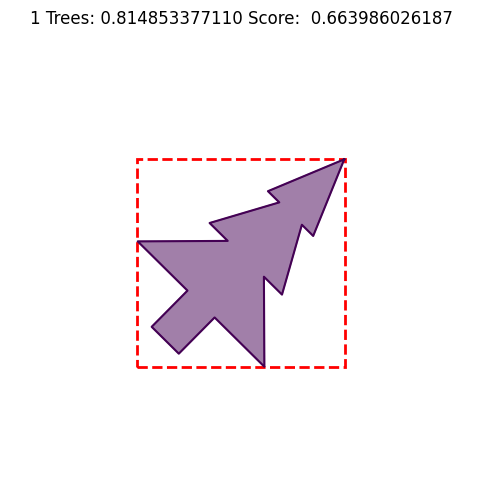

Score: 146.1436594943311176409246
Best Score Updated: 146.1436594943311176409246.
Score: 206.6412048201599125740170
Score: 162.5054545925094295998800
Score: 195.9150570549710326361164
Score: 234.5271668555944735912064
Score: 145.8767061156811895896176
Best Score Updated: 145.8767061156811895896176.
Score: 120.8195463229230174475646
Best Score Updated: 120.8195463229230174475646.
Score: 104.8802838825135218680954
Best Score Updated: 104.8802838825135218680954.
Score: 168.9389280965467083864996
Score: 181.7689831089848747295718
Score: 82.3936189689788428041102
Best Score Updated: 82.3936189689788428041102.
Score: 140.6965994099561640047960
Score: 63.0778999418288236374109
Best Score Updated: 63.0778999418288236374109.
Score: 80.43799013142778513861925
Score: 86.0840079239850994048884
Score: 68.85194592718714602903335
Score: 95.0668047281798614836115
Score: 38.81843655575862659988226
Best Score Updated: 38.81843655575862659988226.
Score: 58.50668421151269445760615
Score: 43.14055618723675

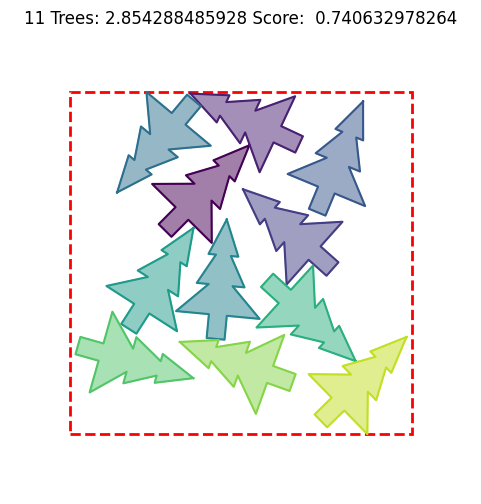

Score: 38.15706269403321723320358
Best Score Updated: 38.15706269403321723320358.
Score: 39.33516270516134949730808
Score: 36.15915702364794791414783
Best Score Updated: 36.15915702364794791414783.
Score: 26.1793143393708504259101
Best Score Updated: 26.1793143393708504259101.
Score: 17.13959043514680529398991
Best Score Updated: 17.13959043514680529398991.
Score: 20.71773101824979144853144
Score: 20.27203176912661286860534
Score: 30.14449689294318027081631
Score: 19.23368677034564268705987
Score: 18.21631427666418323976975
Score: 20.63961494375058196643207
Score: 18.56323556219896754260572
Score: 30.08237232617767704769419
Score: 23.7654311712436579218862
Score: 22.91171993932805574632282
Score: 27.46577643291986183082671
Score: 10.22117954209418762529188
Best Score Updated: 10.22117954209418762529188.
Score: 13.59813224204152811795927
Score: 5.444636625632543620282811
Best Score Updated: 5.444636625632543620282811.
Score: 2.931617461113739592722653
Best Score Updated: 2.9316174611137

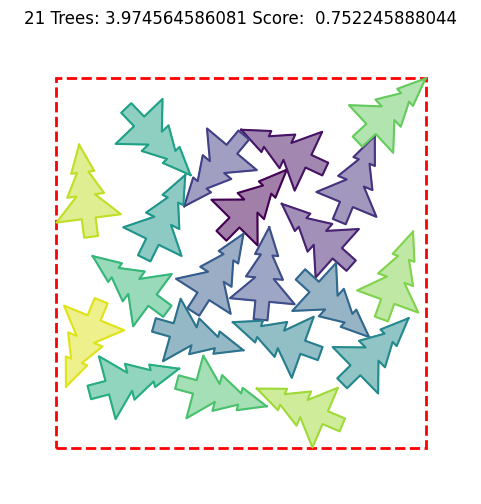

Score: 13.65146833437729128039926
Best Score Updated: 13.65146833437729128039926.
Score: 11.59207766198283298709195
Best Score Updated: 11.59207766198283298709195.
Score: 13.40024376100395846060542
Score: 18.42835057905157422470010
Score: 14.0196282609102209237887
Score: 16.99547853887885572870536
Score: 11.62624437355797589628434
Score: 14.73009190406378516077714
Score: 11.17180695700930205559398
Best Score Updated: 11.17180695700930205559398.
Score: 10.56528860872825150865601
Best Score Updated: 10.56528860872825150865601.
Score: 17.61609551548015562390181
Score: 12.57861203163967802892006
Score: 13.74848771928144038132895
Score: 14.56903775021356062873169
Score: 15.42270755815360608205441
Score: 6.834604580587927451871991
Best Score Updated: 6.834604580587927451871991.
Score: 13.17714208452340318141570
Score: 5.170569591651129874411541
Best Score Updated: 5.170569591651129874411541.
Score: 7.773909225167076221986841
Score: 7.663545470610633706383423
Score: 4.541595779783495304729300

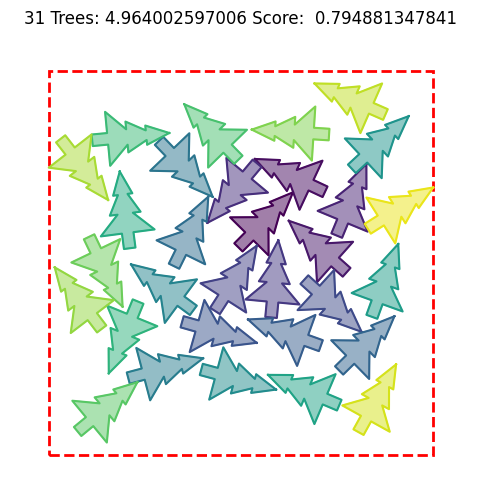

Score: 12.37185577418041975187292
Best Score Updated: 12.37185577418041975187292.
Score: 7.446558253230159655083822
Best Score Updated: 7.446558253230159655083822.
Score: 8.242570036727752884821462
Score: 11.16807894118808969792433
Score: 9.126382113212913285346597
Score: 12.11593740178035533032041
Score: 7.036691516604659549421109
Best Score Updated: 7.036691516604659549421109.
Score: 4.546825848673283614718644
Best Score Updated: 4.546825848673283614718644.
Score: 8.015383620782851690083606
Score: 2.696590720173248358899952
Best Score Updated: 2.696590720173248358899952.
Score: 4.353856654282243563231584
Score: 2.002189190174483409566851
Best Score Updated: 2.002189190174483409566851.
Score: 2.517013722728780231232504
Score: 1.198463654406241925403014
Best Score Updated: 1.198463654406241925403014.
Score: 2.149559378624661172820764
Score: Infinity
Score: Infinity
Score: 2.013028314225058141808713
Score: 3.120510075484281192796504
Score: 2.960071991179138184154879
Score: 2.74746366741

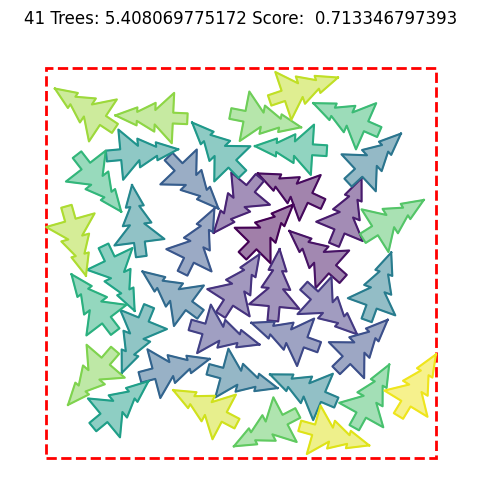

Score: 11.07285128077260624032679
Best Score Updated: 11.07285128077260624032679.
Score: 9.880465122107891521037595
Best Score Updated: 9.880465122107891521037595.
Score: 7.714757323851411933693348
Best Score Updated: 7.714757323851411933693348.
Score: 5.4969917233127998006722
Best Score Updated: 5.4969917233127998006722.
Score: 9.568916753067354148670838
Score: 3.220426590488240499134038
Best Score Updated: 3.220426590488240499134038.
Score: 5.022385957521357211582283
Score: 1.692524980195722256796229
Best Score Updated: 1.692524980195722256796229.
Score: 3.872842120650376888955857
Score: 1.363421267026371917326278
Best Score Updated: 1.363421267026371917326278.
Score: 2.742585842980253958824176
Score: 1.020002980089330557563707
Best Score Updated: 1.020002980089330557563707.
Score: 1.248860757823948591842868
Score: 1.901277155623655398032599
Score: 1.883479204779018387610251
Score: 1.733671573211212680630105
Score: 1.101959838951627383571889
Score: 1.723092845462308118674679
Score: 1

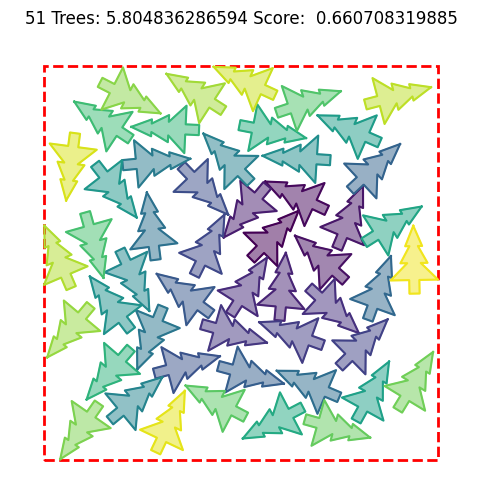

Score: 11.82276405444906885031862
Best Score Updated: 11.82276405444906885031862.
Score: 8.067845594759452074143281
Best Score Updated: 8.067845594759452074143281.
Score: 9.078282383965018785743006
Score: 4.973612562420317281819473
Best Score Updated: 4.973612562420317281819473.
Score: 4.618256178482100362444525
Best Score Updated: 4.618256178482100362444525.
Score: 2.179493728639257525083979
Best Score Updated: 2.179493728639257525083979.
Score: 1.514254514014961018277063
Best Score Updated: 1.514254514014961018277063.
Score: 0.9425319339434106594378567
Best Score Updated: 0.9425319339434106594378567.
Score: 1.073644342340338352362671
Score: 1.529700608211839914174184
Score: 1.416113070669419560706192
Score: 1.484374249790049580641474
Score: 1.602976646374796141503501
Score: Infinity
Score: 1.358891698349256279049750
Score: Infinity
Score: Infinity
Score: 2.422527978275809330347613
Score: Infinity
Score: 0.8061928265215391293949906
Best Score Updated: 0.8061928265215391293949906.
Scor

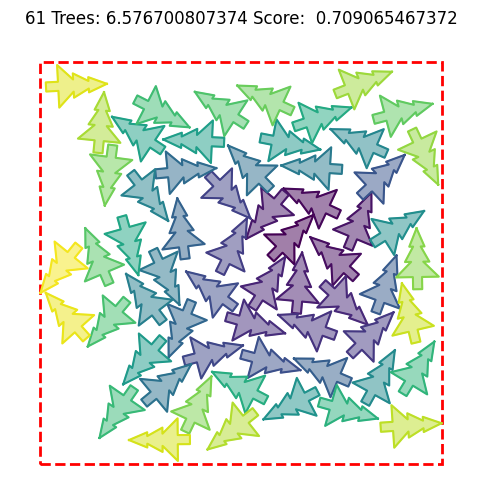

Score: 8.288450778521681007081781
Best Score Updated: 8.288450778521681007081781.
Score: 5.164632569343867168493818
Best Score Updated: 5.164632569343867168493818.
Score: 3.393861310971219242825669
Best Score Updated: 3.393861310971219242825669.
Score: 3.898450281534225179088410
Score: 2.451931678191804867587644
Best Score Updated: 2.451931678191804867587644.
Score: 1.812472025911155917720876
Best Score Updated: 1.812472025911155917720876.
Score: 1.962618570802354764700053
Score: 2.863272895448636309278490
Score: 2.497792715994967815968744
Score: 2.998915391981357292055073
Score: 3.063319674624295807393545
Score: Infinity
Score: 2.817171250921644224945074
Score: 1.995114050305549101036142
Score: 2.800660809690469104252673
Score: 3.650394580362253398438782
Score: 1.831640178030952091715811
Score: 1.111560871671150613567498
Best Score Updated: 1.111560871671150613567498.
Score: 0.8437504460935975317651716
Best Score Updated: 0.8437504460935975317651716.
Score: Infinity
Score: 1.567967986

KeyboardInterrupt: 

In [17]:
tree_data = []
current_placed_trees = []  # Initialize an empty list for the first iteration
total_score = 0
for n in range(200):
    # Pass the current_placed_trees to initialize_trees
    current_placed_trees, side, score = initialize_trees_simulated_aneealing(n+1, existing_trees=current_placed_trees)
    total_score = total_score + score
    if (n%10 == 0):
        plot_results(side, current_placed_trees, n+1, score)
    for tree in current_placed_trees:
        tree_data.append([tree.center_x, tree.center_y, tree.angle])
        
cols = ['x', 'y', 'deg']
submission = pd.DataFrame(
    index=index, columns=cols, data=tree_data).rename_axis('id')

for col in cols:
    submission[col] = submission[col].astype(float).round(decimals=6)
    
# To ensure everything is kept as a string, prepend an 's'
for col in submission.columns:
    submission[col] = 's' + submission[col].astype('string')
submission.to_csv('sample_submission.csv')

print(total_score)